In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.mast import Observations, Mast
from pprint import pprint
from astroquery.esa.jwst import Jwst as jwst
import os
mast = Mast()

# Resolve a single object
target_name = "M42"

# coord = SkyCoord(ra=53, dec=-27, unit=(u.degree, u.degree), frame='icrs')
width = u.Quantity(.1, u.deg)
height = u.Quantity(.1, u.deg)
result = jwst.query_target(target_name=target_name, width=width, height=height)
result

# from astroquery.mast import Observations

obs = Observations.query_object(
    target_name,
    radius="0.1 deg"
)


The User Guide is currently not available.


In [2]:
# Filter for MIRI/IFU public observations
filtered_base = obs[
    (obs['instrument_name'] == 'MIRI/IFU') &
    (obs['dataRights'] == 'PUBLIC')
]

# Define the three filters of interest
target_filters = ['CH4-LONG', 'CH3-LONG', 'CH2-SHORT']

# Create a dictionary to hold results per filter
filtered_by_filter = {}

for f in target_filters:
    filtered_by_filter[f] = filtered_base[filtered_base['filters'] == f]

# Print summary
for f, data in filtered_by_filter.items():
    print(f"\n=== Filter: {f} ===")
    print(f"Count: {len(data)}")
    for row in data:
        print(f"  obs_id: {row['obs_id']} | filters: {row['filters']} | t_exptime: {row['t_exptime']}")

# Optional: combine all three filters into one table
from astropy.table import vstack

all_filtered = vstack([filtered_by_filter[f] for f in target_filters if len(filtered_by_filter[f]) > 0])
print(f"\nTotal across all 3 filters: {len(all_filtered)}")



=== Filter: CH4-LONG ===
Count: 4
  obs_id: jw04332-o001_t001_miri_ch4-long | filters: CH4-LONG | t_exptime: 555.008
  obs_id: jw01288-c1004_t010_miri_ch4-long | filters: CH4-LONG | t_exptime: 4695.3719999999985
  obs_id: jw01288-o002_t010_miri_ch4-long | filters: CH4-LONG | t_exptime: 4695.3719999999985
  obs_id: jw01741-o005_t002_miri_ch4-long | filters: CH4-LONG | t_exptime: 4491.304

=== Filter: CH3-LONG ===
Count: 4
  obs_id: jw04332-o001_t001_miri_ch3-long | filters: CH3-LONG | t_exptime: 555.008
  obs_id: jw01288-c1004_t010_miri_ch3-long | filters: CH3-LONG | t_exptime: 4695.3719999999985
  obs_id: jw01288-o002_t010_miri_ch3-long | filters: CH3-LONG | t_exptime: 4695.3719999999985
  obs_id: jw01741-o005_t002_miri_ch3-long | filters: CH3-LONG | t_exptime: 4491.304

=== Filter: CH2-SHORT ===
Count: 4
  obs_id: jw04332-o001_t001_miri_ch2-short | filters: CH2-SHORT | t_exptime: 555.008
  obs_id: jw01288-c1004_t010_miri_ch2-short | filters: CH2-SHORT | t_exptime: 4695.3719999999985


In [3]:
for f in target_filters:
    filter_obs = all_filtered[all_filtered['filters'] == f]
    
    if len(filter_obs) == 0:
        print(f"No observations found for filter {f}, skipping...")
        continue
    
    first = filter_obs[0]
    dataURL = first['dataURL']
    
    if not dataURL:
        print(f"No dataURL for filter {f}, skipping...")
        continue

    save_dir = f"./fits_images/{target_name}"
    os.makedirs(save_dir, exist_ok=True)

    filename = dataURL.split("/")[-1]
    local_path = f"{save_dir}/{filename}"

    # Skip if file already exists
    if os.path.exists(local_path):
        print(f"  Already exists, skipping: {local_path}")
        continue

    print(f"Downloading {f}: {filename}")
    Observations.download_file(dataURL, local_path=local_path)
    print(f"  Saved to {local_path}")

  Already exists, skipping: ./fits_images/M42/jw04332-o001_t001_miri_ch4-long_s3d.fits
  Already exists, skipping: ./fits_images/M42/jw04332-o001_t001_miri_ch3-long_s3d.fits
  Already exists, skipping: ./fits_images/M42/jw04332-o001_t001_miri_ch2-short_s3d.fits


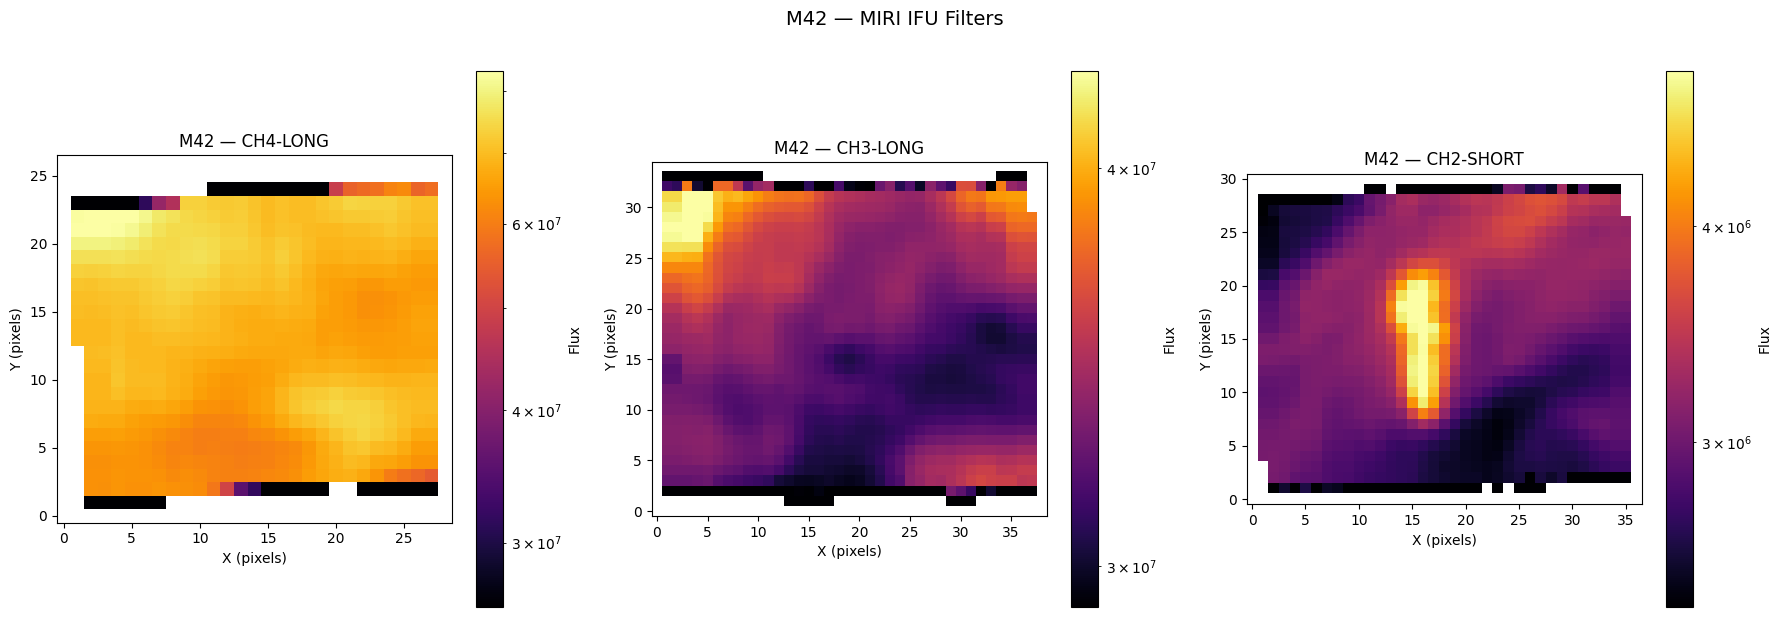

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, f in enumerate(target_filters):
    filter_obs = all_filtered[all_filtered['filters'] == f]

    if len(filter_obs) == 0:
        print(f"No observations found for filter {f}, skipping...")
        continue

    dataURL = filter_obs[0]['dataURL']
    filename = dataURL.split("/")[-1]
    local_path = f"./fits_images/{target_name}/{filename}"

    if not os.path.exists(local_path):
        print(f"File not found for filter {f}: {local_path}")
        continue

    hdul = fits.open(local_path)
    cube = hdul[1].data

    image = np.nansum(cube, axis=0)

    # Replace non-positive values so LogNorm doesn't break
    image = np.where(image <= 0, np.nan, image)

    vmin = np.nanpercentile(image, 5)
    vmax = np.nanpercentile(image, 99)

    # Ensure vmin is positive for LogNorm
    vmin = max(vmin, 1e-10)
    if vmin >= vmax:
        vmax = vmin * 10  # fallback if image is nearly uniform

    ax = axes[i]
    im = ax.imshow(
        image,
        origin='lower',
        cmap='inferno',
        norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
    )
    ax.set_title(f"{target_name} — {f}", fontsize=12)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    plt.colorbar(im, ax=ax, label="Flux")
    hdul.close()

plt.suptitle(f"{target_name} — MIRI IFU Filters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
first_obs = all_filtered[all_filtered['filters'] == target_filters[2]][0]
print (first_obs)
print(first_obs['dataURL'])

intentType obs_collection provenance_name instrument_name project  filters  wavelength_region target_name target_classification              obs_id                     s_ra             s_dec       dataproduct_type      proposal_pi      calib_level       t_min              t_max       t_exptime em_min em_max                                                 obs_title                                                 t_obs_release proposal_id proposal_type sequence_number                                                     s_region                                                                             jpegURL                                                     dataURL                           dataRights mtFlag srcDen   obsid        distance     
---------- -------------- --------------- --------------- ------- --------- ----------------- ----------- --------------------- -------------------------------- ----------------- ----------------- ---------------- --------------------- --------

In [8]:
filtered_1 = obs[
    (obs['instrument_name'] == 'MIRI/IFU')
]
filtered_2 = filtered_1[
    (filtered_1['dataRights'] == 'PUBLIC')
]
filtered_3 = filtered_2[
    (filtered_2['filters'] == 'CH4-LONG')
]
for k in range (len(filtered_2)):
    print (filtered_2[k])
    # print ()
print (len(filtered_2))
filtered_2[1]['dataURL']


intentType obs_collection provenance_name instrument_name project filters wavelength_region target_name target_classification             obs_id                s_ra         s_dec        dataproduct_type    proposal_pi    calib_level t_min t_max t_exptime em_min em_max                                              obs_title                                              t_obs_release proposal_id proposal_type sequence_number                                                            s_region                                                            jpegURL dataURL dataRights mtFlag srcDen   obsid        distance     
---------- -------------- --------------- --------------- ------- ------- ----------------- ----------- --------------------- ------------------------------ --------- ------------------ ---------------- ----------------- ----------- ----- ----- --------- ------ ------ --------------------------------------------------------------------------------------------------- ---------

masked